In [3]:
# Big Mart Sales Prediction Using Machine Learning

## Introduction

#This project aims to predict the sales of products at different Big Mart outlets using machine learning.

#The dataset contains information about products and outlets, such asitem weight, item visibility, item type, MRP, outlet size, location and
#outlet type.
## Problem Statement

#To develop a machine learning model that predicts the sales of a product at a particular Big Mart outlet using product-related and outlet-related
#features.

# 1. Importing Required Libraries
#The following libraries are used for data handling, numerical operations and basic data visualization."

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 2. Loading the Training Dataset

#The training dataset contains the input features as well as the target variable, Item_Outlet_Sales. We use this dataset to train our machine
#learning models.

In [5]:
train = pd.read_csv("Train.csv")

train.head()


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


## 3. Loading the Test Dataset
#The test dataset contains the input features but does not contain the target variable. After training our model, we will use this dataset
#to make predictions.

In [6]:
test = pd.read_csv("Test.csv")

test.head()


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


## 4. Understanding the Training Dataset
#We check the number of rows and columns to understand the size of the training dataset.

In [7]:
print("Rows:", train.shape[0])
print("Columns:", train.shape[1])


Rows: 8523
Columns: 12


## 5. Understanding the Test Dataset
#We check the size of the test dataset. The test dataset has one less column because it does not contain the target variable.

In [8]:
print("Rows:", test.shape[0])
print("Columns:", test.shape[1])


Rows: 5681
Columns: 11


## 6. Dataset Features
#We display the column names to understand the information available in the dataset.

In [9]:
print(train.columns)


Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')


## 7. Checking Data Types
#We check the data type of each column. This helps us identify numerical and categorical features and decide what preprocessing is required.

In [10]:
train.dtypes


Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
Item_Outlet_Sales            float64
dtype: object

## 8. Dataset Information
#The info() function gives information about the columns, data types and number of non-null values. This helps us identify missing data.

In [11]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


## 9. Statistical Summary
#the describe() function gives basic statistical information about numerical columns such as mean, minimum, maximum and standard deviation.

In [12]:
train.describe()


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


#Since Item_Outlet_Sales is a continuous numerical value, this project is a regression problem

In [13]:
print(train["Item_Outlet_Sales"].head())


0    3735.1380
1     443.4228
2    2097.2700
3     732.3800
4     994.7052
Name: Item_Outlet_Sales, dtype: float64


In [ ]:
print("Target variable:", "Item_Outlet_Sales")
print("Minimum sales:", train["Item_Outlet_Sales"].min())-
print("Maximum sales:", train["Item_Outlet_Sales"].max())


Target variable: Item_Outlet_Sales
Minimum sales: 33.29
Maximum sales: 13086.9648


## 11. Checking Missing Values
#Missing values can affect the performance of a machine learning model.
#Therefore, we check each column to identify missing values.

In [15]:
train.isnull().sum()


Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

## 5. Checking Duplicate Records
#Duplicate rows can affect the analysis and model results. Therefore,we check whether duplicate records are present in the dataset.

In [16]:
train.duplicated().sum()


0

## 15. Distribution of Item Outlet Sales

#We plot the distribution of the target variable to understand how the
#sales values are spread across the dataset.

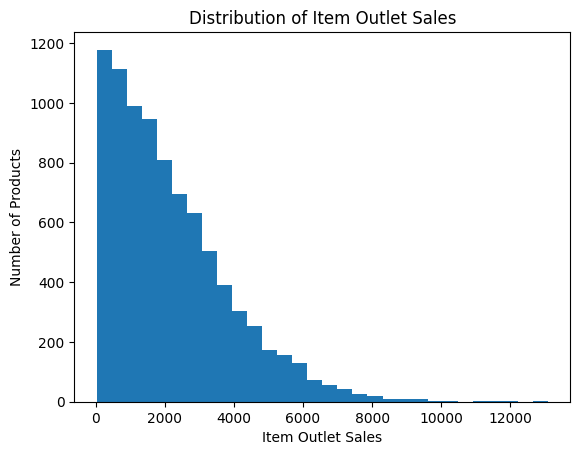

In [17]:
plt.hist(train["Item_Outlet_Sales"], bins=30)
plt.xlabel("Item Outlet Sales")
plt.ylabel("Number of Products")
plt.title("Distribution of Item Outlet Sales")
plt.show()


## 16. Item MRP and Sales

#We compare Item MRP with Item Outlet Sales to check whether product
#price has a relationship with sales.

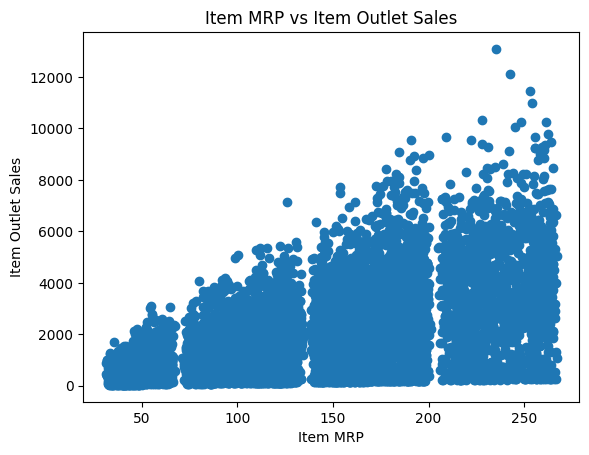

In [18]:
plt.scatter(train["Item_MRP"], train["Item_Outlet_Sales"])
plt.xlabel("Item MRP")
plt.ylabel("Item Outlet Sales")
plt.title("Item MRP vs Item Outlet Sales")
plt.show()


## 17. Sales According to Outlet Type

#Different outlet types may have different sales patterns. We compare
#the average sales for each outlet type.

Outlet_Type
Grocery Store         339.828500
Supermarket Type1    2316.181148
Supermarket Type2    1995.498739
Supermarket Type3    3694.038558
Name: Item_Outlet_Sales, dtype: float64


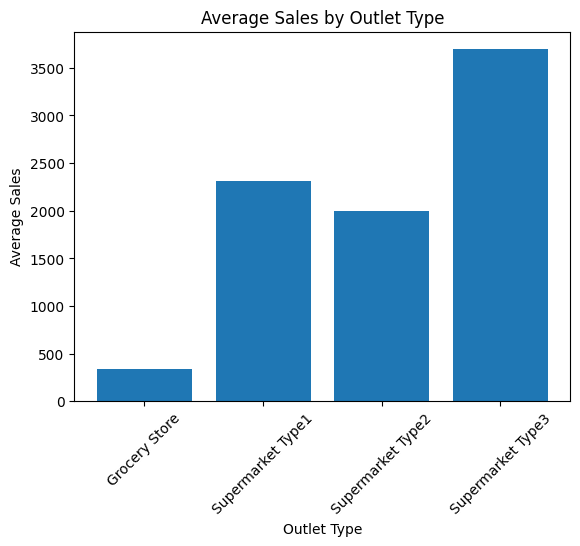

In [19]:
outlet_sales = train.groupby("Outlet_Type")["Item_Outlet_Sales"].mean()

print(outlet_sales)
plt.bar(outlet_sales.index, outlet_sales.values)
plt.xlabel("Outlet Type")
plt.ylabel("Average Sales")
plt.title("Average Sales by Outlet Type")
plt.xticks(rotation=45)
plt.show()


## 18. Sales According to Item Type
#We compare the average sales of different product categories to
#understand whether sales vary across item types.

Item_Type
Baking Goods             1952.971207
Breads                   2204.132226
Breakfast                2111.808651
Canned                   2225.194904
Dairy                    2232.542597
Frozen Foods             2132.867744
Fruits and Vegetables    2289.009592
Hard Drinks              2139.221622
Health and Hygiene       2010.000265
Household                2258.784300
Meat                     2158.977911
Others                   1926.139702
Seafood                  2326.065928
Snack Foods              2277.321739
Soft Drinks              2006.511735
Starchy Foods            2374.332773
Name: Item_Outlet_Sales, dtype: float64


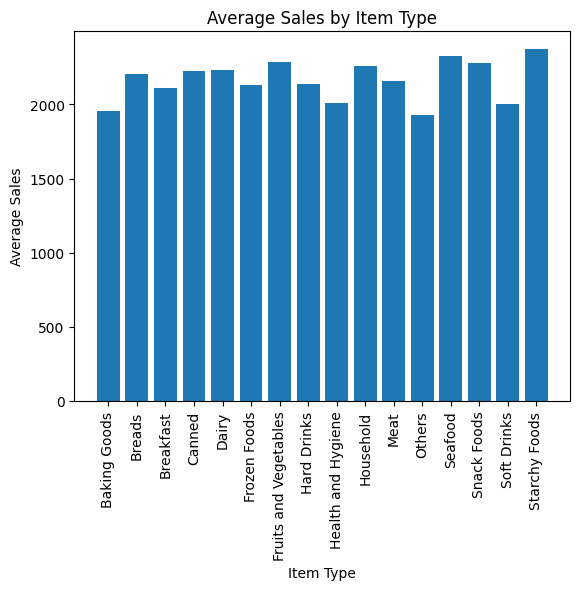

In [20]:
item_sales = train.groupby("Item_Type")["Item_Outlet_Sales"].mean()

print(item_sales)
plt.bar(item_sales.index, item_sales.values)
plt.xlabel("Item Type")
plt.ylabel("Average Sales")
plt.title("Average Sales by Item Type")
plt.xticks(rotation=90)
plt.show()


## 19. Checking for Outliers

#Outliers are values that are unusually high or low compared with most of the observations.

#We check numerical features using box plots before deciding whether outlier treatment is required.

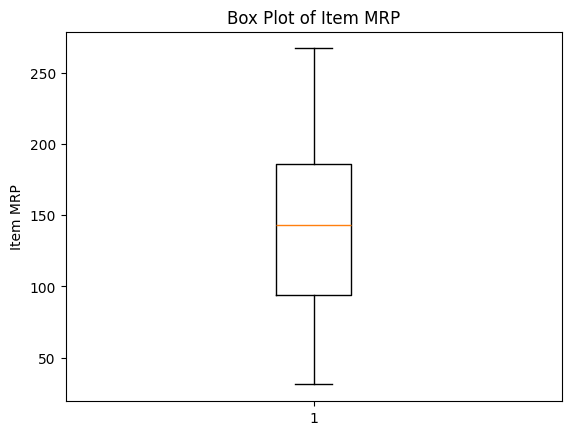

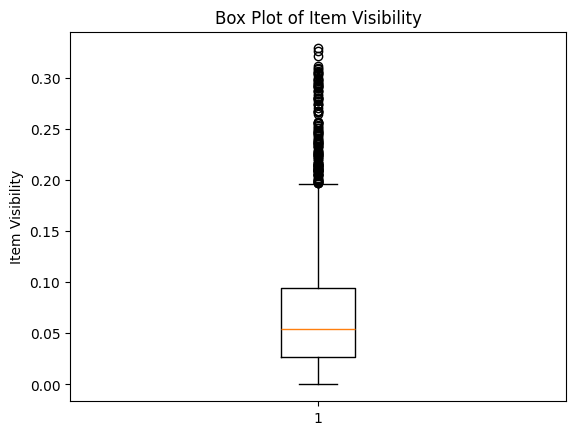

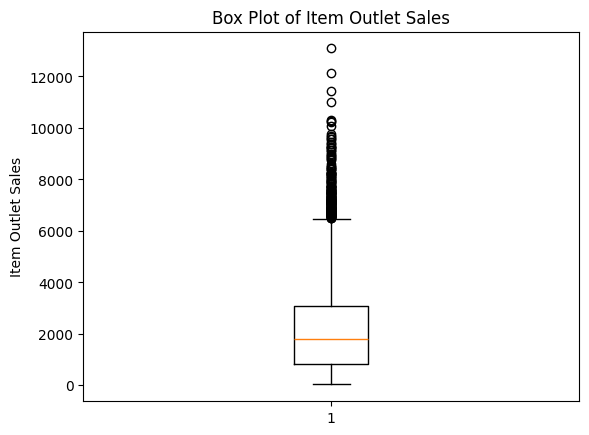

In [21]:
plt.boxplot(train["Item_MRP"].dropna())
plt.ylabel("Item MRP")
plt.title("Box Plot of Item MRP")
plt.show()
plt.boxplot(train["Item_Visibility"].dropna())
plt.ylabel("Item Visibility")
plt.title("Box Plot of Item Visibility")
plt.show()
plt.boxplot(train["Item_Outlet_Sales"].dropna())
plt.ylabel("Item Outlet Sales")
plt.title("Box Plot of Item Outlet Sales")
plt.show()


## 20. Checking Categories in Categorical Features

#We examine the unique values in important categorical columns. Thishelps us understand the categories before converting them into numbers.

In [22]:
print("Item Fat Content:")
print(train["Item_Fat_Content"].unique())

print("\nOutlet Size:")
print(train["Outlet_Size"].unique())

print("\nOutlet Location Type:")
print(train["Outlet_Location_Type"].unique())

print("\nOutlet Type:")
print(train["Outlet_Type"].unique())


Item Fat Content:
['Low Fat' 'Regular' 'low fat' 'LF' 'reg']

Outlet Size:
['Medium' nan 'High' 'Small']

Outlet Location Type:
['Tier 1' 'Tier 3' 'Tier 2']

Outlet Type:
['Supermarket Type1' 'Supermarket Type2' 'Grocery Store'
 'Supermarket Type3']


## 21. Cleaning Item Fat Content

#Some values in Item_Fat_Content represent the same category but are written differently. We standardize these values so that similar
#categories are treated as one category.

In [23]:
train["Item_Fat_Content"] = train["Item_Fat_Content"].replace(
    {"LF": "Low Fat", "low fat": "Low Fat", "reg": "Regular"}
)

train["Item_Fat_Content"].unique()


array(['Low Fat', 'Regular'], dtype=object)

## 22. Handling Missing Values in Item Weight

#Item_Weight contains missing values. Since it is a numerical feature,we replace the missing values with the median Item_Weight.
#The median is used because it is less affected by extreme values.

In [24]:
train["Item_Weight"] = train["Item_Weight"].fillna(
    train["Item_Weight"].median()
)

print("Missing Item_Weight values:",
      train["Item_Weight"].isnull().sum())


Missing Item_Weight values: 0


## 23. Handling Missing Values in Outlet Size

#Outlet_Size is a categorical feature with missing values. We replace the missing values with the mode, which is the most frequently occurring
#category in the column.

In [25]:
train["Outlet_Size"] = train["Outlet_Size"].fillna(
    train["Outlet_Size"].mode()[0]
)

print("Missing Outlet_Size values:",
      train["Outlet_Size"].isnull().sum())


Missing Outlet_Size values: 0


## 24. Verifying Missing Values

#After handling the missing values, we check the dataset again to make sure that the required missing values have been handled.

In [26]:
train.isnull().sum()


Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

## 25. Feature Engineering - Outlet Age
#The outlet establishment year tells us when the outlet was started.We create a new feature called Outlet_Age to represent the age of
#the outlet.

#This may help the model understand whether the age of an outlet has
#an effect on sales.

In [27]:
train["Outlet_Age"] = 2026 - train["Outlet_Establishment_Year"]

train[["Outlet_Establishment_Year", "Outlet_Age"]].head()


,Outlet_Establishment_Year,Outlet_Age
0,1999,27
1,2009,17
2,1999,27
3,1998,28
4,1987,39


## 26. Selecting Features

#We examine the available features before building the machine learning models. The target variable Item_Outlet_Sales is kept separately because
#it is the value we want to predict.

In [28]:
print(train.columns.tolist())


['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales', 'Outlet_Age']


## 27. Separating Features and Target

#The input features are stored in X and the target variable is stored in y.

#The model will learn the relationship between X and y and later use the features in X to predict sales.

In [29]:
X = train.drop("Item_Outlet_Sales", axis=1)
y = train["Item_Outlet_Sales"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)


Features:
Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Outlet_Age'],
      dtype='object')

Target:
Item_Outlet_Sales


## 28. Removing Identifier Columns

#Item_Identifier and Outlet_Identifier are identification numbers.They identify products and outlets but do not directly represent
#measurable characteristics.

#Therefore, these columns are removed before model training.

In [30]:
X = X.drop(["Item_Identifier", "Outlet_Identifier"], axis=1)

X.head()


,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Outlet_Age
0,9.30,Low Fat,0.016047,Dairy,249.8092,1999,Medium,Tier 1,Supermarket Type1,27
1,5.92,Regular,0.019278,Soft Drinks,48.2692,2009,Medium,Tier 3,Supermarket Type2,17
2,17.50,Low Fat,0.016760,Meat,141.6180,1999,Medium,Tier 1,Supermarket Type1,27
3,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,1998,Medium,Tier 3,Grocery Store,28
4,8.93,Low Fat,0.000000,Household,53.8614,1987,High,Tier 3,Supermarket Type1,39


## 29. Removing the Original Establishment Year

#We have already created the Outlet_Age feature from Outlet_Establishment_Year.

#Therefore, we remove the original year column to avoid keeping two features representing similar information.

In [31]:
X = X.drop("Outlet_Establishment_Year", axis=1)

X.head()


,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,Outlet_Age
0,9.30,Low Fat,0.016047,Dairy,249.8092,Medium,Tier 1,Supermarket Type1,27
1,5.92,Regular,0.019278,Soft Drinks,48.2692,Medium,Tier 3,Supermarket Type2,17
2,17.50,Low Fat,0.016760,Meat,141.6180,Medium,Tier 1,Supermarket Type1,27
3,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,Medium,Tier 3,Grocery Store,28
4,8.93,Low Fat,0.000000,Household,53.8614,High,Tier 3,Supermarket Type1,39


## 30. Final Input Features

#We display the remaining features that will be used for machine learning after feature engineering and feature selection.

In [32]:
print(X.columns.tolist())


['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Outlet_Age']


## 31. Identifying Categorical Features

#Machine learning models require numerical input. Therefore, we identify the categorical columns that need to be converted into numerical form.

In [33]:
categorical_columns = X.select_dtypes(include="object").columns

print(categorical_columns)


Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type'],
      dtype='object')


## 32. Encoding Categorical Features

#The categorical features are converted into numerical values using one-hot encoding.

#This allows the machine learning algorithms to use categorical information during model training.

In [34]:
X = pd.get_dummies(X, columns=categorical_columns, drop_first=True)

X.head()


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Age,Item_Fat_Content_Regular,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,...,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.30,0.016047,249.8092,27,False,False,False,False,True,False,...,False,False,False,True,False,False,False,True,False,False
1,5.92,0.019278,48.2692,17,True,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
2,17.50,0.016760,141.6180,27,False,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
3,19.20,0.000000,182.0950,28,True,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
4,8.93,0.000000,53.8614,39,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False


## 33. Checking the Final Dataset

#After encoding the categorical features, we check the shape of the dataset and make sure that the data is ready for splitting into
#training and validation sets.

In [35]:
print("Number of rows:", X.shape[0])
print("Number of features:", X.shape[1])


Number of rows: 8523
Number of features: 27


## 34. Splitting the Dataset

#The dataset is divided into training and testing portions. 80% of the data is used for training the machine learning models and
#20% is used for evaluating their performance on unseen data.

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (6818, 27)
Testing data: (1705, 27)


### Checking Training and Testing Data

In this cell, I make sure that the training and testing variables are available before building the machine learning models.

The training data is used to train the models, while the testing data is used to check how well the models perform on unseen data.

In [37]:
# Make variable names consistent

if 'X_train' in globals():
    x_train = X_train

if 'X_test' in globals():
    x_test = X_test

if 'y_train' in globals():
    y_train = y_train

if 'y_test' in globals():
    y_test = y_test

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (6818, 27)
Testing data shape: (1705, 27)
Training target shape: (6818,)
Testing target shape: (1705,)


### Linear Regression Model

Linear Regression is used as the first model because it is a simple regression algorithm and can be used as a baseline model.

The model learns the relationship between the input features and Item Outlet Sales.

In [38]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(x_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Prediction using Linear Regression

In this cell, the trained Linear Regression model is used to predict Item Outlet Sales for the test data.

The test data was not used while training the model, so these predictions represent predictions on unseen data.

In [39]:
linear_predictions = linear_model.predict(x_test)

print("First 10 predictions:")
print(linear_predictions[:10])

First 10 predictions:
[1359.05604052  762.00752867  820.0497195  4228.86673066 3292.55609448
  579.16582096 4754.10905096 2048.96656818 1392.08396186 2785.24024397]


### Evaluation of Linear Regression

The Linear Regression model is evaluated using MAE, RMSE and R².

MAE and RMSE measure prediction error, so lower values are better.
R² shows how much variation in Item Outlet Sales is explained by the model, so a higher value is better.

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R2 Score:", linear_r2)

Linear Regression Results
-------------------------
MAE : 791.5962967286048
RMSE: 1068.944413395381
R2 Score: 0.5795972247952184


In [50]:
import numpy as np
from scipy.stats import f

# Predictions on training data
y_train_pred = linear_model.predict(x_train)

# Number of observations and features
n = len(y_train)
p = x_train.shape[1]

# Total Sum of Squares
y_mean = np.mean(y_train)
sst = np.sum((y_train - y_mean) ** 2)

# Residual Sum of Squares
sse = np.sum((y_train - y_train_pred) ** 2)

# Regression Sum of Squares
ssr = sst - sse

# Degrees of freedom
df_model = p
df_error = n - p - 1

# F-statistic
f_statistic = (ssr / df_model) / (sse / df_error)

# Overall model p-value
p_value = f.sf(f_statistic, df_model, df_error)

print("Linear Regression Statistical Analysis")
print("---------------------------------------")
print("R2 Score :", linear_r2)
print("F-statistic :", f_statistic)
print("P-value :", p_value)

if p_value < 0.05:
    print("Result: The Linear Regression model is statistically significant.")
else:
    print("Result: The Linear Regression model is not statistically significant.")

Linear Regression Statistical Analysis
---------------------------------------
R2 Score : 0.5795972247952184
F-statistic : 318.83534351756435
P-value : 0.0
Result: The Linear Regression model is statistically significant.


In [55]:
import pandas as pd
import numpy as np
from scipy.stats import t

# Convert x_train into a DataFrame
X = pd.DataFrame(x_train).copy()

# Convert categorical columns into numbers
X = pd.get_dummies(X, drop_first=True)

# Convert all columns to numeric
X = X.astype(float)

# Remove columns with missing or infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna(axis=1)

# Convert target variable to numeric
y = pd.Series(y_train).astype(float).values

# Add intercept
X = np.column_stack([np.ones(len(X)), X])

# Calculate coefficients
beta = np.linalg.pinv(X.T @ X) @ X.T @ y

# Calculate predictions
y_pred = X @ beta

# Calculate residuals
residuals = y - y_pred

# Number of observations and parameters
n = X.shape[0]
k = X.shape[1]

# Degrees of freedom
df = n - k

# Residual variance
mse = np.sum(residuals ** 2) / df

# Standard error
cov_matrix = mse * np.linalg.pinv(X.T @ X)
standard_error = np.sqrt(np.diag(cov_matrix))

# t-statistic
t_stat = beta / standard_error

# p-value
p_values = 2 * t.sf(np.abs(t_stat), df)

# Display p-values
print("LINEAR REGRESSION P-VALUE ANALYSIS")
print("----------------------------------")

print("Number of observations:", n)
print("Number of features:", k - 1)
print()

for i, p in enumerate(p_values):
    if i == 0:
        name = "Intercept"
    else:
        name = "Feature " + str(i)

    print(name, " : p-value =", round(p, 6))

print()
print("Significance level = 0.05")

if np.any(p_values[1:] < 0.05):
    print("Result: Some features are statistically significant.")
else:
    print("Result: No feature is statistically significant at 0.05.")

LINEAR REGRESSION P-VALUE ANALYSIS
----------------------------------
Number of observations: 6818
Number of features: 27

Intercept  : p-value = 0.660407
Feature 1  : p-value = 0.598923
Feature 2  : p-value = 0.09931
Feature 3  : p-value = 0.0
Feature 4  : p-value = 0.004567
Feature 5  : p-value = 0.164119
Feature 6  : p-value = 0.812116
Feature 7  : p-value = 0.588438
Feature 8  : p-value = 0.708509
Feature 9  : p-value = 0.212925
Feature 10  : p-value = 0.860137
Feature 11  : p-value = 0.451233
Feature 12  : p-value = 0.914702
Feature 13  : p-value = 0.853594
Feature 14  : p-value = 0.834874
Feature 15  : p-value = 0.984552
Feature 16  : p-value = 0.676579
Feature 17  : p-value = 0.180505
Feature 18  : p-value = 0.903142
Feature 19  : p-value = 0.724907
Feature 20  : p-value = 0.817894
Feature 21  : p-value = 0.003963
Feature 22  : p-value = 0.005929
Feature 23  : p-value = 0.027565
Feature 24  : p-value = 0.01276
Feature 25  : p-value = 0.0
Feature 26  : p-value = 0.0
Feature 27  :

### Ridge Regression Model

Ridge Regression is a regularized version of Linear Regression.

Regularization is used to reduce the effect of very large model coefficients and can help control overfitting.

I selected Ridge Regression because the assignment asks us to apply regularization when it is useful for the dataset.

In [56]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(x_train, y_train)

print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


### Prediction using Ridge Regression

The trained Ridge Regression model is used to predict sales for the unseen test data.

In [57]:
ridge_predictions = ridge_model.predict(x_test)

print("First 10 predictions:")
print(ridge_predictions[:10])

First 10 predictions:
[1357.18495609  764.57003212  816.96698862 4223.8026532  3290.85391045
  575.98437835 4749.74368155 2047.10621307 1390.59437723 2782.78664556]


### Evaluation of Ridge Regression

The Ridge model is evaluated using MAE, RMSE and R².

These values will also be compared with Linear Regression to check whether regularization improved the model.

In [58]:
ridge_mae = mean_absolute_error(y_test, ridge_predictions)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_predictions))
ridge_r2 = r2_score(y_test, ridge_predictions)

print("Ridge Regression Results")
print("-----------------------")
print("MAE :", ridge_mae)
print("RMSE:", ridge_rmse)
print("R2 Score:", ridge_r2)

Ridge Regression Results
-----------------------
MAE : 791.5098847436565
RMSE: 1069.0804035014157
R2 Score: 0.5794902514973423


### Decision Tree Regression

Decision Tree Regression is used to model non-linear relationships between the input features and sales.

Unlike Linear Regression, a decision tree makes predictions using a series of decision rules.

In [59]:
from sklearn.tree import DecisionTreeRegressor

decision_tree_model = DecisionTreeRegressor(random_state=42)

decision_tree_model.fit(x_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


### Prediction using Decision Tree

The trained Decision Tree model is used to predict Item Outlet Sales for the test dataset.

In [60]:
decision_tree_predictions = decision_tree_model.predict(x_test)

print("First 10 predictions:")
print(decision_tree_predictions[:10])

First 10 predictions:
[ 322.2472  703.0848  690.4346 5000.8238  796.2968  432.77   5313.084
  421.4514  685.1082 4586.0304]


### Evaluation of Decision Tree

The Decision Tree predictions are evaluated using MAE, RMSE and R².

The results will help us determine whether the Decision Tree is suitable for this sales prediction problem.

In [61]:
dt_mae = mean_absolute_error(y_test, decision_tree_predictions)
dt_rmse = np.sqrt(mean_squared_error(y_test, decision_tree_predictions))
dt_r2 = r2_score(y_test, decision_tree_predictions)

print("Decision Tree Results")
print("--------------------")
print("MAE :", dt_mae)
print("RMSE:", dt_rmse)
print("R2 Score:", dt_r2)

Decision Tree Results
--------------------
MAE : 1043.1539625806452
RMSE: 1517.0050258824708
R2 Score: 0.15330037044252798


### Random Forest Regression

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees.

It is used here because it can capture non-linear relationships and is generally more powerful than using a single decision tree.

In [62]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(x_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Prediction using Random Forest

The trained Random Forest model is used to predict Item Outlet Sales for the unseen test data.

In [63]:
random_forest_predictions = random_forest_model.predict(x_test)

print("First 10 predictions:")
print(random_forest_predictions[:10])

First 10 predictions:
[ 834.08095   937.699404  831.337854 4941.807288 2119.527694  452.098174
 5422.022196 1496.944772 1083.303206 2728.155448]


### Evaluation of Random Forest

The Random Forest model is evaluated using MAE, RMSE and R².

The results are compared with the previous Linear Regression, Ridge Regression and Decision Tree models.

In [64]:
rf_mae = mean_absolute_error(y_test, random_forest_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, random_forest_predictions))
rf_r2 = r2_score(y_test, random_forest_predictions)

print("Random Forest Results")
print("--------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Results
--------------------
MAE : 768.7465817478005
RMSE: 1099.7984287909715
R2 Score: 0.5549779599019931


### Random Forest Hyperparameter Tuning

The original Random Forest model gives a reasonable result, so hyperparameter tuning is applied to improve its performance.

GridSearchCV tests different combinations of Random Forest parameters using cross-validation.

The best parameter combination is then selected based on the validation results.

In [65]:
from sklearn.model_selection import GridSearchCV

parameter_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    parameter_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

Best parameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


### Tuned Random Forest Model

The best Random Forest parameters obtained from GridSearchCV are used to create the final tuned model.

This model is trained using the complete training dataset.

In [66]:
tuned_random_forest = grid_search.best_estimator_

tuned_random_forest.fit(x_train, y_train)

print("Tuned Random Forest model trained successfully.")

Tuned Random Forest model trained successfully.


### Prediction using Tuned Random Forest

The tuned Random Forest model is used to predict sales for the unseen test data.

This is the prediction from the model that will be considered for final model selection.

In [67]:
tuned_rf_predictions = tuned_random_forest.predict(x_test)

print("First 10 predictions:")
print(tuned_rf_predictions[:10])

First 10 predictions:
[1088.50295768  766.40156503  689.88429113 4947.67724297 3034.99654101
  460.9322016  5573.91203472 1542.91754665 1274.26618762 2668.81415788]


### Evaluation of Tuned Random Forest

The tuned model is evaluated using MAE, RMSE and R².

This result is compared with the original Random Forest model to check whether hyperparameter tuning improved the model.

In [68]:
tuned_rf_mae = mean_absolute_error(y_test, tuned_rf_predictions)
tuned_rf_rmse = np.sqrt(mean_squared_error(y_test, tuned_rf_predictions))
tuned_rf_r2 = r2_score(y_test, tuned_rf_predictions)

print("Tuned Random Forest Results")
print("---------------------------")
print("MAE :", tuned_rf_mae)
print("RMSE:", tuned_rf_rmse)
print("R2 Score:", tuned_rf_r2)

Tuned Random Forest Results
---------------------------
MAE : 737.5114549850532
RMSE: 1053.9105610787983
R2 Score: 0.5913393291574989


### Comparison of All Regression Models

In this cell, the performance of all the trained models is compared using MAE, RMSE and R².

A lower MAE and RMSE indicate lower prediction error, while a higher R² indicates better performance.

This comparison is used to select the final model.

In [69]:
model_results = {
    "Linear Regression": [linear_mae, linear_rmse, linear_r2],
    "Ridge Regression": [ridge_mae, ridge_rmse, ridge_r2],
    "Decision Tree": [dt_mae, dt_rmse, dt_r2],
    "Random Forest": [rf_mae, rf_rmse, rf_r2],
    "Tuned Random Forest": [tuned_rf_mae, tuned_rf_rmse, tuned_rf_r2]
}

for model, values in model_results.items():
    print(model)
    print("MAE :", values[0])
    print("RMSE:", values[1])
    print("R2  :", values[2])
    print()

Linear Regression
MAE : 791.5962967286048
RMSE: 1068.944413395381
R2  : 0.5795972247952184

Ridge Regression
MAE : 791.5098847436565
RMSE: 1069.0804035014157
R2  : 0.5794902514973423

Decision Tree
MAE : 1043.1539625806452
RMSE: 1517.0050258824708
R2  : 0.15330037044252798

Random Forest
MAE : 768.7465817478005
RMSE: 1099.7984287909715
R2  : 0.5549779599019931

Tuned Random Forest
MAE : 737.5114549850532
RMSE: 1053.9105610787983
R2  : 0.5913393291574989



### Model Performance Comparison Table

The results are displayed in a table so that the performance of all models can be easily compared.

In [70]:
import pandas as pd

comparison = pd.DataFrame(
    model_results,
    index=["MAE", "RMSE", "R2 Score"]
).T

print(comparison)

                             MAE         RMSE  R2 Score
Linear Regression     791.596297  1068.944413  0.579597
Ridge Regression      791.509885  1069.080404  0.579490
Decision Tree        1043.153963  1517.005026  0.153300
Random Forest         768.746582  1099.798429  0.554978
Tuned Random Forest   737.511455  1053.910561  0.591339


### Final Model Selection

The best model is selected based on the evaluation results.

For this regression problem, the model should have low MAE and RMSE and high R².

Based on the obtained results, Tuned Random Forest is selected as the final model.

In [71]:
best_model_name = comparison["R2 Score"].idxmax()

print("Best Model:", best_model_name)
print()
print("Reason:")
print("It has the highest R2 Score and the lowest MAE and RMSE among the tested models.")

Best Model: Tuned Random Forest

Reason:
It has the highest R2 Score and the lowest MAE and RMSE among the tested models.


## Sample Prediction Using Unseen Data

In this step, one sample is taken from the test dataset. The test data was not used during model training, so it can be treated as unseen data.

The selected best model is used to predict the Item Outlet Sales for this sample. The actual and predicted values are then compared.

In [81]:
# Select one sample from the unseen test data

sample = X_test.iloc[[0]]

# Get the actual target value
actual_value = y_test.iloc[0]

# Predict using the best model
predicted_value = tuned_random_forest.predict(sample)[0]

# Calculate the prediction error
error = abs(actual_value - predicted_value)

print("SAMPLE UNSEEN DATA PREDICTION")
print("-----------------------------")
print("Actual Item Outlet Sales    :", actual_value)
print("Predicted Item Outlet Sales :", predicted_value)
print("Absolute Error              :", error)

SAMPLE UNSEEN DATA PREDICTION
-----------------------------
Actual Item Outlet Sales    : 1743.0644
Predicted Item Outlet Sales : 1088.5029576839875
Absolute Error              : 654.5614423160125


## Prediction Result

The actual and predicted sales values are displayed below. The absolute error shows the difference between the actual sales value and the value predicted by the selected model.

In [ ]:
print("Prediction Result")
print("-----------------")
print("Actual Value    :", round(actual_value, 2))
print("Predicted Value :", round(predicted_value, 2))
print("Absolute Error  :", round(error, 2))

## Final Conclusion

The BigMart Sales dataset was used to develop a machine learning model for predicting Item Outlet Sales.

The dataset was first explored and preprocessed. Missing values, duplicate records and outliers were checked, and the required categorical features were converted into numerical form.

Five regression models were developed and evaluated using MAE, RMSE and R² score. Ridge Regression was used for regularization and Random Forest was further improved using hyperparameter tuning.

After comparing all the models, Tuned Random Forest was selected as the best model because it achieved the lowest MAE and RMSE and the highest R² score.

The selected model was also tested on an unseen test sample. The actual and predicted sales values were compared to demonstrate the prediction capability of the final model.

In [82]:
print("FINAL CONCLUSION")
print("----------------")

print("Problem Type : Regression")
print("Target Variable : Item_Outlet_Sales")
print("Best Model : Tuned Random Forest")
print()

print("Model Performance")
print("-----------------")
print("MAE      :", tuned_rf_mae)
print("RMSE     :", tuned_rf_rmse)
print("R2 Score :", tuned_rf_r2)

print()

print("Final Result:")
print("Tuned Random Forest was selected as the final model")
print("because it achieved the best overall performance.")

FINAL CONCLUSION
----------------
Problem Type : Regression
Target Variable : Item_Outlet_Sales
Best Model : Tuned Random Forest

Model Performance
-----------------
MAE      : 737.5114549850532
RMSE     : 1053.9105610787983
R2 Score : 0.5913393291574989

Final Result:
Tuned Random Forest was selected as the final model
because it achieved the best overall performance.
